# 1. `NUM_TICKS` and `SECONDS_PER_TICK` Stability Analysis

Determines optimal simulation discretization parameters via empirical stability sweeps.
- **SPT**: Maximize while keeping CV ≤ 5% (at fixed simulated duration).
- **num_ticks**: Minimize while keeping CV ≤ 5% (at conservative SPT via bisection).

Tested across route scales and passenger spawn rates.
**Output**: `rnd/csv/rnd1_stability_results.csv`

In [1]:
# ==========================================
# TESTING MODE TOGGLE
# True  = fast QA run (your PC)
# False = full production run (friend's PC)
# ==========================================
testing_mode = False

In [2]:
import os, sys, time, gc, random, yaml
import numpy as np
import pandas as pd

sys.path.insert(0, os.getcwd())
random.seed(42)
np.random.seed(42)

from utils_simplified import (
    reuse_citygraph, reuse_ddm, generate_route_system,
    generate_dummy_yaml, SimEnvironment, run_simulations_parallel
)

cg_pkl = "rnd/pkl/profile_p1.pkl"
ddm_pkl = "rnd/pkl/ddm_8am.pkl"

print("Loading cached CityGraph and DDM...")
t0 = time.time()
G_city = reuse_citygraph(cg_pkl)
ddm = reuse_ddm(ddm_pkl)
print(f"Loaded in {time.time()-t0:.1f}s | {len(G_city.nodes)} nodes, {len(G_city.graph)} edges")

if testing_mode:
    print("\n--- TESTING MODE ---")
    ROUTE_COUNTS     = [3, 6]
    PASSENGER_RATES  = [200, 600]
    REPLICATIONS     = 3
    JEEPS_PER_ROUTE  = 10
    SPT_VALUES       = [10, 40, 160]
    FIXED_SIM_S      = 600      # 10 min simulated for SPT sweep
    BISECT_BOUNDS    = (60, 500) # ticks
    BISECT_ITERS     = 3
else:
    print("\n--- PRODUCTION MODE ---")
    ROUTE_COUNTS     = [3, 6, 10, 14, 18]    # 5 scales (maps the curve perfectly)
    PASSENGER_RATES  = [200, 600, 1000]      # 3 rates = 15 total scenarios
    REPLICATIONS     = 7                     # Maxes out the 8-core CPU (minus one core)
    JEEPS_PER_ROUTE  = 10
    SPT_VALUES       = [10, 20, 40, 80, 160] # Dropped 320s
    FIXED_SIM_S      = 1200                  # 20 mins simulated (speeds up Phase 1)
    BISECT_BOUNDS    = (50, 1200)            # Slashes bisection time by capping max ticks
    BISECT_ITERS     = 4                     # 4 iters instead of 5 (faster Phase 2)

CV_THRESHOLD = 0.05
os.makedirs("rnd/csv", exist_ok=True)
os.makedirs("rnd/configs", exist_ok=True)

print(f"Route counts: {ROUTE_COUNTS}")
print(f"Spawn rates:  {PASSENGER_RATES} pax/hr")
print(f"Replications: {REPLICATIONS} (run in parallel)")
print(f"SPT sweep:    {SPT_VALUES} (fixed {FIXED_SIM_S}s simulated)")
print(f"Bisection:    {BISECT_BOUNDS}, {BISECT_ITERS} iters")

Loading cached CityGraph and DDM...
[INFO] Reusing CityGraph from pickle file: rnd/pkl/profile_p1.pkl
[INFO] Reusing DirectDemandSampler from pickle file: rnd/pkl/ddm_8am.pkl
Loaded in 2.3s | 36866 nodes, 76310 edges

--- PRODUCTION MODE ---
Route counts: [3, 6, 10, 14, 18]
Spawn rates:  [200, 600, 1000] pax/hr
Replications: 7 (run in parallel)
SPT sweep:    [10, 20, 40, 80, 160] (fixed 1200s simulated)
Bisection:    (50, 1200), 4 iters


In [ ]:
def compute_cv(scores):
    if len(scores) < 2:
        return 1.0
    arr = np.array(scores, dtype=float)
    m = arr.mean()
    return (arr.std(ddof=1) / m) if m > 1e-9 else 1.0


def evaluate_cv_parallel(routes, spt, num_ticks, pass_rate):
    n_jeeps = len(routes) * JEEPS_PER_ROUTE
    yaml_path = f"rnd/configs/_rnd1_s{spt}_t{num_ticks}_r{len(routes)}_p{int(pass_rate)}.yaml"
    generate_dummy_yaml(
        yaml_path,
        **{
            "simulation.seconds_per_tick":        spt,
            "simulation.num_ticks":               num_ticks,
            "simulation.spawn_rate_per_hour":      pass_rate,
            "simulation.total_allocatable_jeeps":  n_jeeps,
            "cg_pkl": cg_pkl,
            "ddm_pkl": ddm_pkl,
        }
    )

    class MockJS:
        def __init__(self, r): self.routes = r

    envs = [
        SimEnvironment(
            tg=None, yaml_file=yaml_path,
            jeep_system=MockJS(routes), sampler=ddm,
            delete_yaml_when_done=(i == REPLICATIONS - 1)
        )
        for i in range(REPLICATIONS)
    ]

    results = run_simulations_parallel(envs)
    scores = [r.score for r in results if r is not None]
    cv = compute_cv(scores)

    del envs, results
    gc.collect()
    return cv, np.mean(scores) if scores else float('nan'), scores

In [4]:
all_results = []
total_scenarios = len(ROUTE_COUNTS) * len(PASSENGER_RATES)
scenario_i = 0

for n_routes in ROUTE_COUNTS:
    random.seed(42 + n_routes)
    np.random.seed(42 + n_routes)
    print(f"\n{'='*70}")
    print(f"GENERATING {n_routes} ROUTES...")
    t0 = time.time()
    routes = generate_route_system(n_routes, G_city, ddm)
    print(f"  {n_routes} routes, {sum(len(r.path) for r in routes)} edges, "
          f"{n_routes*JEEPS_PER_ROUTE} jeeps | {time.time()-t0:.1f}s")

    for pass_rate in PASSENGER_RATES:
        scenario_i += 1
        print(f"\n{'─'*60}")
        print(f"SCENARIO {scenario_i}/{total_scenarios}: R={n_routes}, Rate={pass_rate}/hr")
        print(f"{'─'*60}")

        # ── Phase 1: SPT Sweep ──
        # Fixed SIMULATED DURATION, so num_ticks = FIXED_SIM_S / spt.
        # Higher SPT → fewer ticks → faster probes.
        print(f"  [SPT Sweep] fixed_sim={FIXED_SIM_S}s")
        optimal_spt = SPT_VALUES[0]
        spt_log = []

        for spt in SPT_VALUES:
            num_ticks = max(10, FIXED_SIM_S // spt)
            t0 = time.time()
            cv, mean_fit, scores = evaluate_cv_parallel(routes, spt, num_ticks, pass_rate)
            wall = time.time() - t0
            status = 'PASS' if cv <= CV_THRESHOLD else 'FAIL'
            print(f"    SPT={spt:3d}s ticks={num_ticks:4d} | "
                  f"CV={cv:.4f} mean={mean_fit:.1f} | {wall:.0f}s | {status}")
            spt_log.append({'spt': spt, 'ticks': num_ticks, 'cv': cv})

            if cv <= CV_THRESHOLD:
                optimal_spt = spt
            else:
                print(f"    -> Early stop")
                break

        print(f"  -> Optimal SPT: {optimal_spt}s")

        # ── Phase 2: Ticks Bisection ──
        print(f"  [Ticks Bisect] spt={optimal_spt}s, range={BISECT_BOUNDS}")
        lo, hi = BISECT_BOUNDS
        optimal_ticks = hi
        ticks_log = []

        for bi in range(BISECT_ITERS):
            mid = (lo + hi) // 2
            t0 = time.time()
            class MockJS:
                def __init__(self, routes):
                    self.routes = routes


            def compute_cv(scores):
                if len(scores) < 2:
                    return 1.0
                arr = np.array(scores, dtype=float)
                m = arr.mean()
                return (arr.std(ddof=1) / m) if m > 1e-9 else 1.0


            def evaluate_cv_parallel(routes, spt, num_ticks, pass_rate):
                n_jeeps = len(routes) * JEEPS_PER_ROUTE
                yaml_path = f"rnd/configs/_rnd1_s{spt}_t{num_ticks}_r{len(routes)}_p{int(pass_rate)}.yaml"
                generate_dummy_yaml(
                    yaml_path,
                    **{
                        "simulation.seconds_per_tick":        spt,
                        "simulation.num_ticks":               num_ticks,
                        "simulation.spawn_rate_per_hour":      pass_rate,
                        "simulation.total_allocatable_jeeps":  n_jeeps,
                        "cg_pkl": cg_pkl,
                        "ddm_pkl": ddm_pkl,
                    }
                )

                envs = [
                    SimEnvironment(
                        tg=None, yaml_file=yaml_path,
                        jeep_system=MockJS(routes), sampler=ddm,
                        delete_yaml_when_done=(i == REPLICATIONS - 1)
                    )
                    for i in range(REPLICATIONS)
                ]

                results = run_simulations_parallel(envs)
                scores = [r.score for r in results if r is not None]
                cv = compute_cv(scores)

                del envs, results
                gc.collect()
                return cv, np.mean(scores) if scores else float('nan'), scores
            wall = time.time() - t0
            status = 'PASS' if cv <= CV_THRESHOLD else 'FAIL'
            print(f"    iter {bi+1}/{BISECT_ITERS}: ticks={mid:4d} | "
                  f"CV={cv:.4f} mean={mean_fit:.1f} | {wall:.0f}s | {status}")
            ticks_log.append({'ticks': mid, 'cv': cv})

            if cv <= CV_THRESHOLD:
                optimal_ticks = mid
                hi = mid - 1
            else:
                lo = mid + 1

        sim_min = (optimal_ticks * optimal_spt) / 60
        print(f"  -> Optimal ticks: {optimal_ticks} ({sim_min:.0f} sim min)")

        all_results.append({
            "num_routes": n_routes, "passenger_rate": pass_rate,
            "optimal_spt": optimal_spt, "optimal_ticks": optimal_ticks,
            "sim_duration_min": sim_min,
            "spt_log": str(spt_log), "ticks_log": str(ticks_log),
        })
        pd.DataFrame(all_results).to_csv(
            "rnd/csv/rnd1_stability_results_partial.csv", index=False)

    del routes
    gc.collect()

df = pd.DataFrame(all_results)
df.to_csv("rnd/csv/rnd1_stability_results.csv", index=False)
print(f"\n{'='*70}")
print("EXPERIMENT COMPLETE — rnd/csv/rnd1_stability_results.csv")
print(f"{'='*70}")
print(df.to_string(index=False))


GENERATING 3 ROUTES...
[INFO] Generating 3 routes...
  3 routes, 8728 edges, 30 jeeps | 0.3s

────────────────────────────────────────────────────────────
SCENARIO 1/15: R=3, Rate=200/hr
────────────────────────────────────────────────────────────
  [SPT Sweep] fixed_sim=1200s
[INFO] Generating dummy YAML at rnd/configs/_rnd1_s10_t120_r3_p200.yaml with overrides: {'simulation.seconds_per_tick': 10, 'simulation.num_ticks': 120, 'simulation.spawn_rate_per_hour': 200, 'simulation.total_allocatable_jeeps': 30, 'cg_pkl': 'rnd/pkl/profile_p1.pkl', 'ddm_pkl': 'rnd/pkl/ddm_8am.pkl'}
[ParallelRunner] Starting parallel execution across 7 CPU cores for 7 setups...
[Worker 24935] Initializing static CityGraph and Sampler...
[Worker 24935] Loading CityGraph from rnd/pkl/profile_p1.pkl...
[Worker 24937] Initializing static CityGraph and Sampler...
[Worker 24937] Loading CityGraph from rnd/pkl/profile_p1.pkl...
[Worker 24938] Initializing static CityGraph and Sampler...
[Worker 24938] Loading CityGr

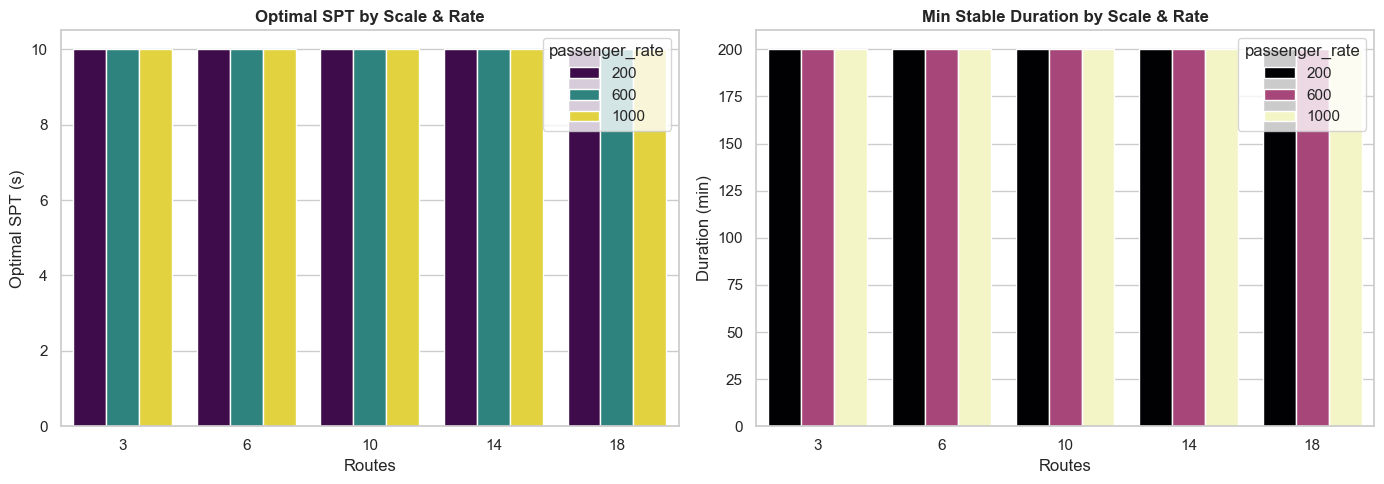

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

df = pd.read_csv("rnd/csv/rnd1_stability_results.csv")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=df, x="num_routes", y="optimal_spt", hue="passenger_rate",
            palette="viridis", ax=ax1)
ax1.set_title("Optimal SPT by Scale & Rate", fontweight="bold")
ax1.set_xlabel("Routes"); ax1.set_ylabel("Optimal SPT (s)")

sns.barplot(data=df, x="num_routes", y="sim_duration_min", hue="passenger_rate",
            palette="magma", ax=ax2)
ax2.set_title("Min Stable Duration by Scale & Rate", fontweight="bold")
ax2.set_xlabel("Routes"); ax2.set_ylabel("Duration (min)")

plt.tight_layout()
os.makedirs("rnd/images", exist_ok=True)
plt.savefig("rnd/images/rnd1_stability.png", dpi=150, bbox_inches="tight")
plt.show()